In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("ToyotaCorolla - MLR.csv")
print(df.head())
print(df.info())
print(df.describe())

   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null  

In [2]:
df['Fuel_Type'] = df['Fuel_Type'].map({
    'Petrol': 0,
    'Diesel': 1,
    'CNG': 2
})

In [3]:
print(df.isnull().sum())
df.fillna(df.mean(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


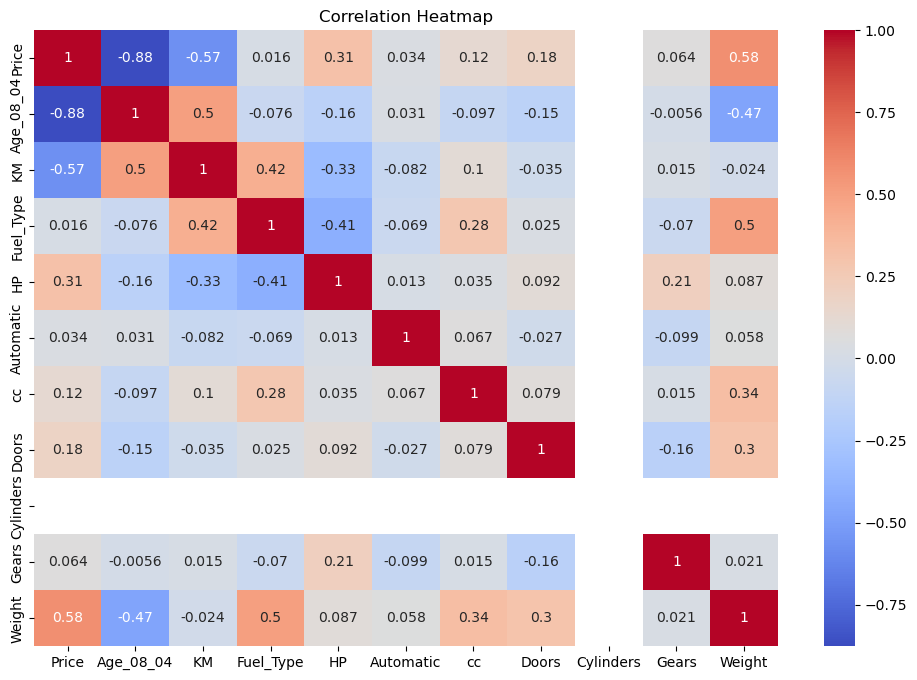

In [4]:
#correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

E:\Users\SUGANYA P\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


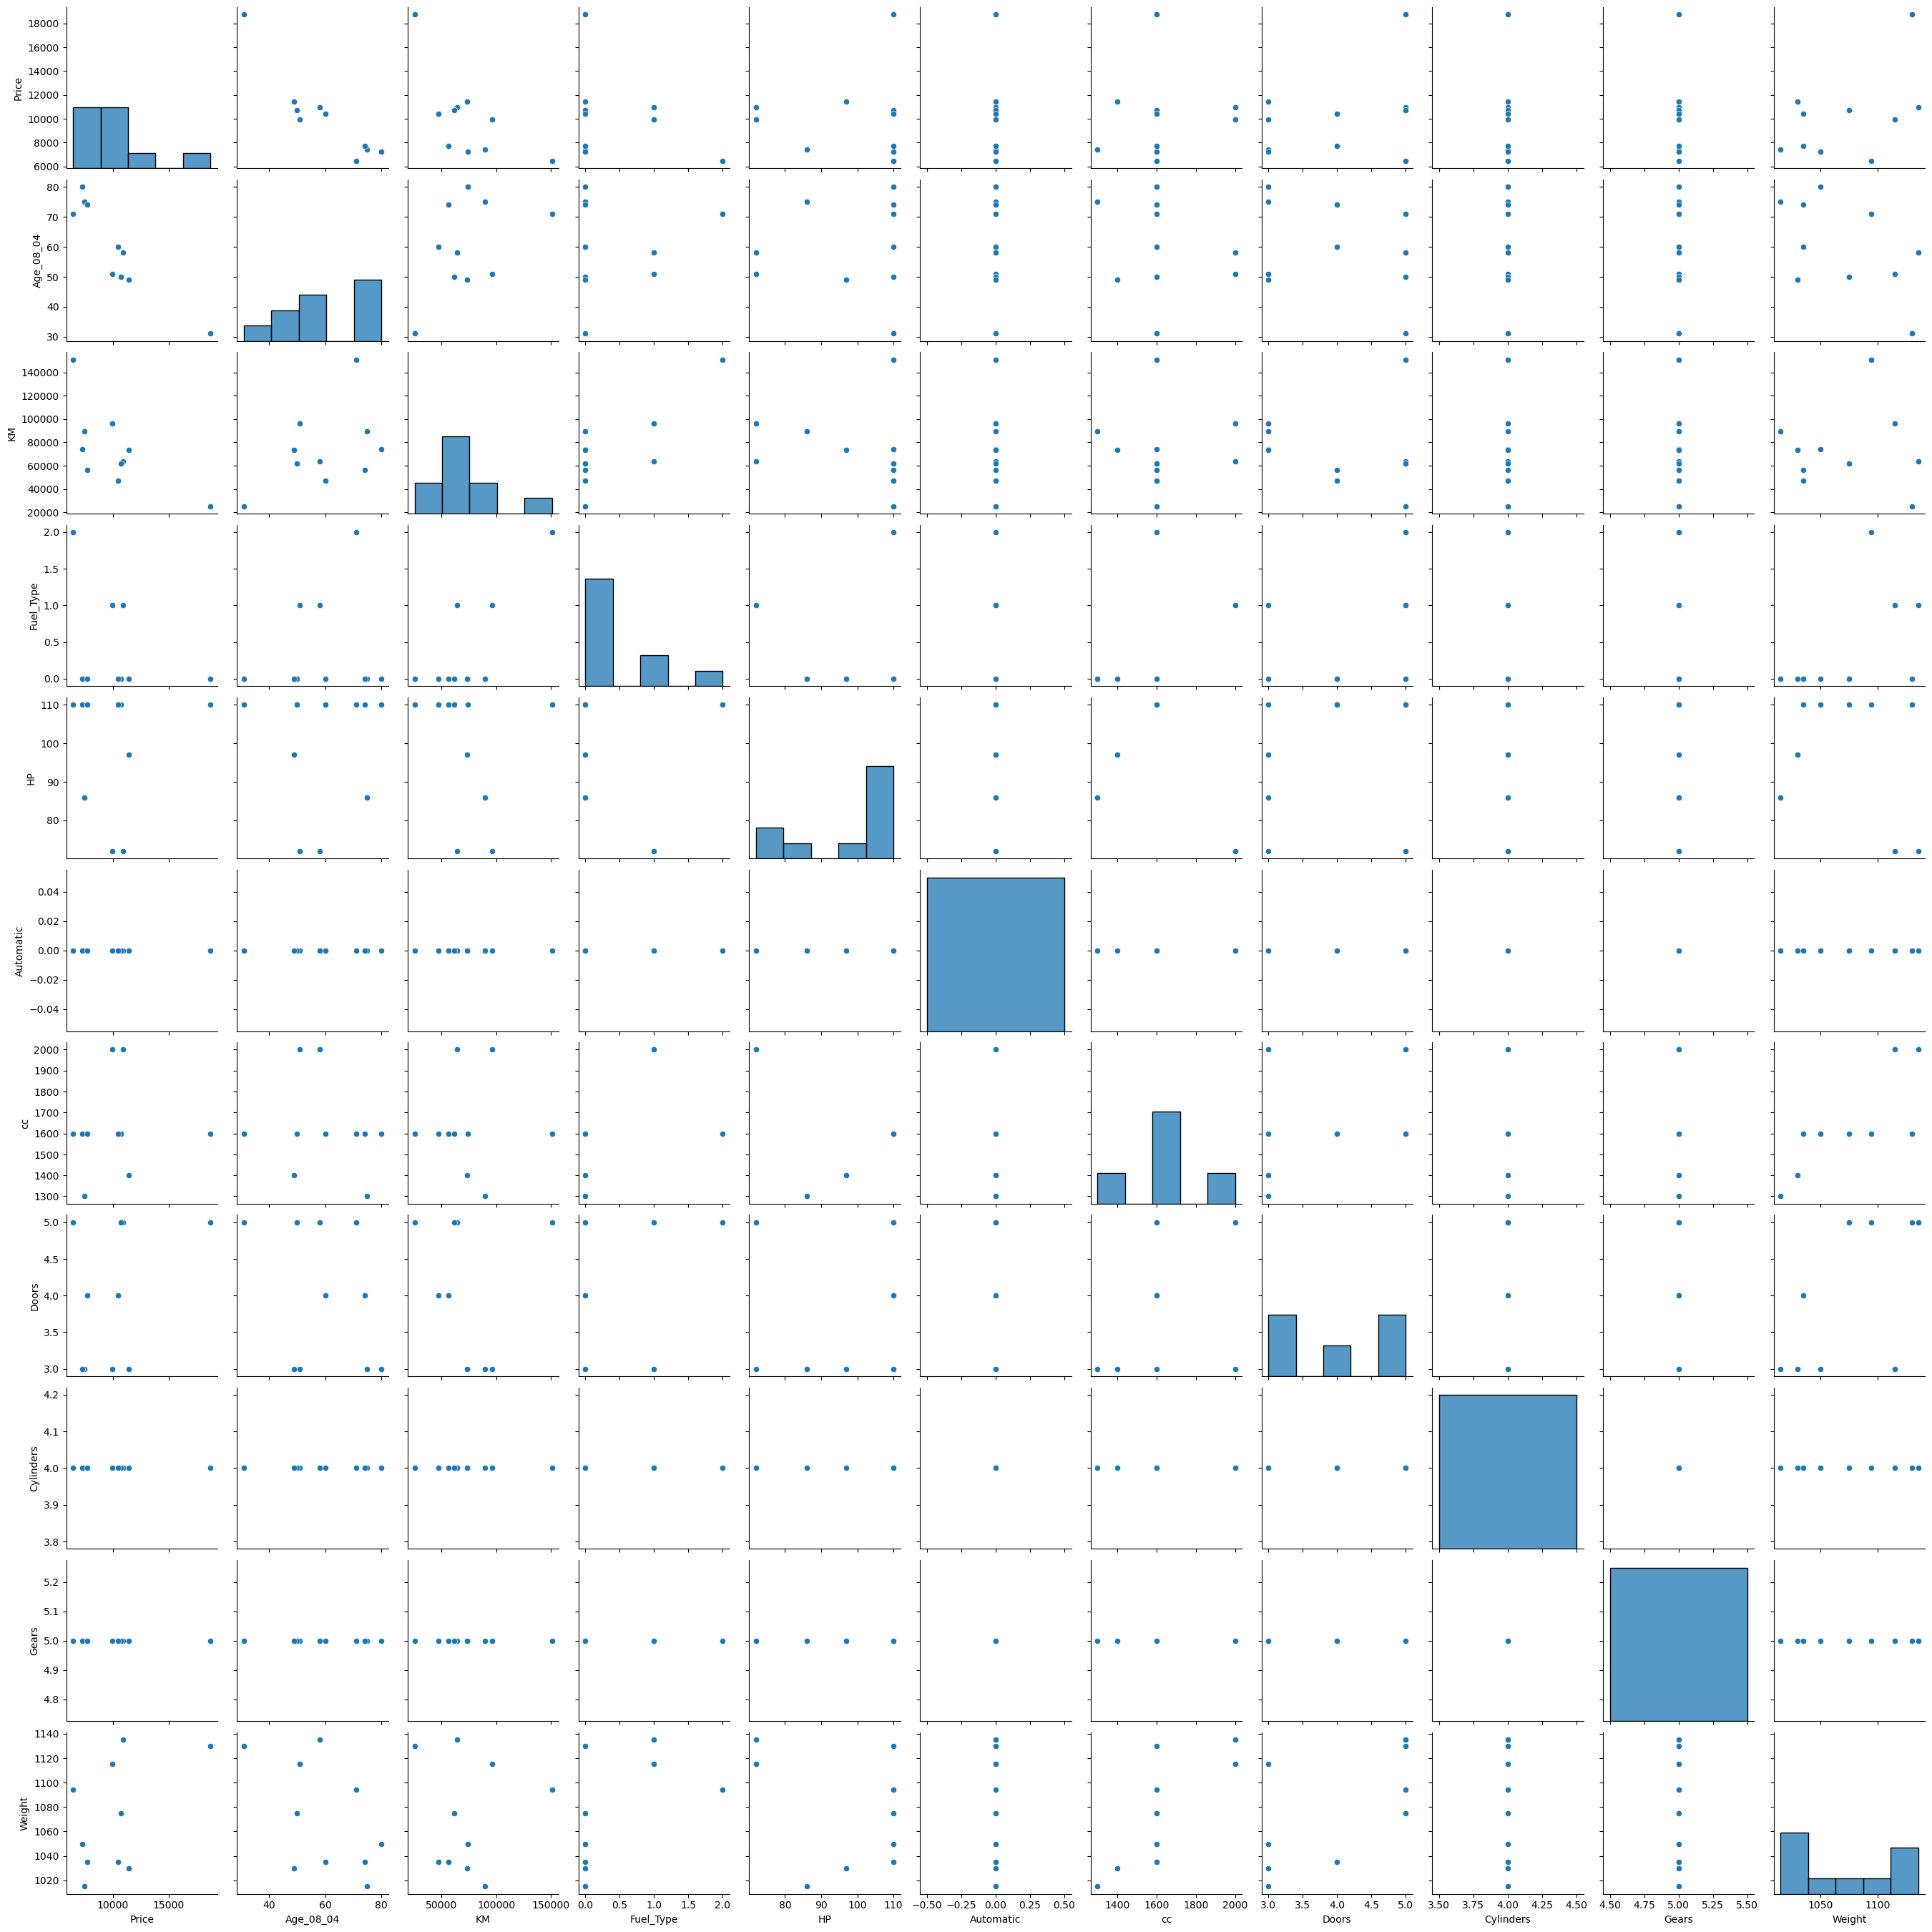

In [5]:
#pairplot
sns.pairplot(df.sample(10))
plt.show()

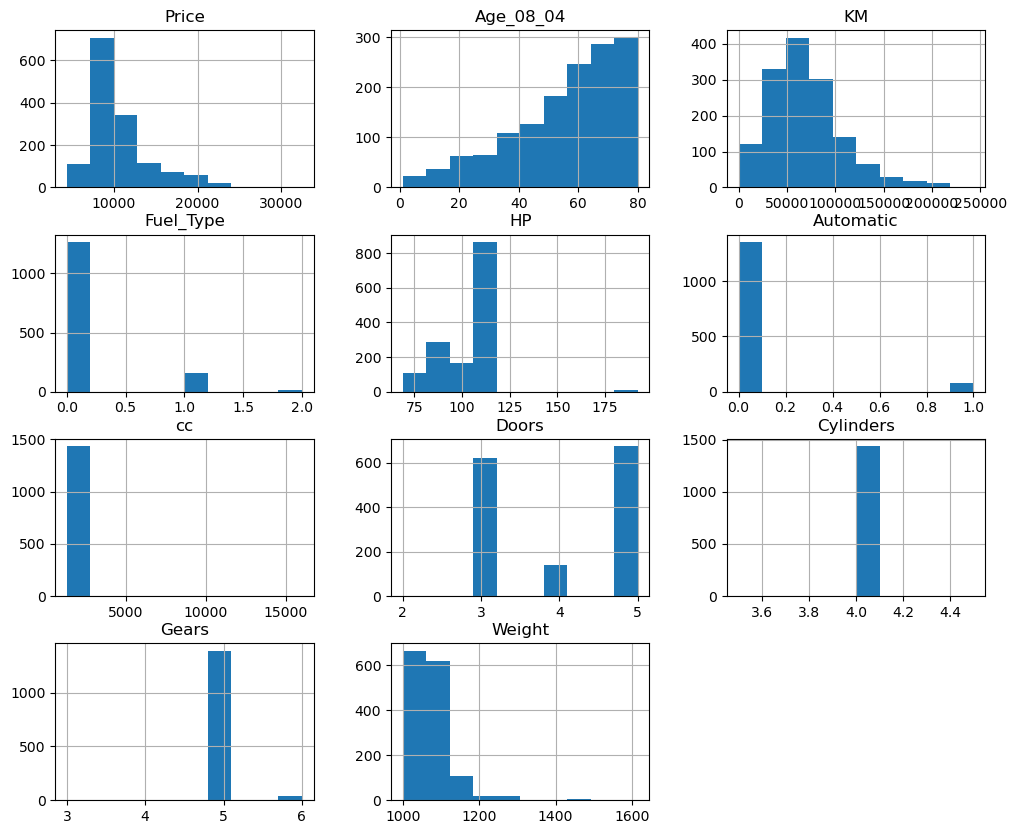

In [6]:
#Distribution Plot
df.hist(figsize=(12,10))
plt.show()

In [7]:
#Feature Selection
X = df.drop('Price', axis=1)
y = df['Price']

In [8]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
#Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
#Model1 Basic Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.8327471995993047
RMSE: 1416.5289337378663


In [11]:
#Model2 Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso R2:", r2_score(y_test, y_pred_lasso))

Lasso R2: 0.8327670357550464


In [12]:
#Model3 Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge R2:", r2_score(y_test, y_pred_ridge))

Ridge R2: 0.8328379398076756


In [16]:
#Coefficient Interpretation
coeff_df = pd.DataFrame(
    lr.coef_,
    index=X.columns,
    columns=['Coefficient']
)

print(coeff_df)

# Find weakest feature
weak_feature = coeff_df['Coefficient'].abs().idxmin()

print("Weakest Feature:", weak_feature)

            Coefficient
Age_08_04 -2.278022e+03
KM        -6.355361e+02
Fuel_Type -3.144047e+02
HP         3.545090e+02
Automatic  8.356147e+01
cc        -4.496289e+01
Doors     -5.747129e+01
Cylinders -5.684342e-14
Gears      7.962799e+01
Weight     1.194949e+03
Weakest Feature: Cylinders


In [14]:
#Comparison
print("Linear Regression R2:", r2_score(y_test, y_pred))
print("Lasso R2:", r2_score(y_test, y_pred_lasso))
print("Ridge R2:", r2_score(y_test, y_pred_ridge))

Linear Regression R2: 0.8327471995993047
Lasso R2: 0.8327670357550464
Ridge R2: 0.8328379398076756


In [15]:
# Model 3-Linear Regression after removing weakest feature
X_new = df.drop(['Price', weak_feature], axis=1)
y = df['Price']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

# Scaling
scaler2 = StandardScaler()
X_train2 = scaler2.fit_transform(X_train2)
X_test2 = scaler2.transform(X_test2)

# Train model
lr2 = LinearRegression()
lr2.fit(X_train2, y_train2)

y_pred2 = lr2.predict(X_test2)

print("New Model R2:", r2_score(y_test2, y_pred2))
print("New Model RMSE:", np.sqrt(mean_squared_error(y_test2, y_pred2)))

New Model R2: 0.8327471995993045
New Model RMSE: 1416.528933737867
